In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from src import utils
from src import mobi

In [2]:
def get_tomtom_stat_sig_test(tomtom_summary_dir, nbp_list, rank_list, tool, top, standard):
    
    nn_data = []
    for nn in nbp_list:
        rank_data = []
        for rank in rank_list:
            data = pd.read_csv(
                "%s/%s_%s_%d_count_%s.txt" % (tomtom_summary_dir, tool, rank, nn, top),
                sep="\t",
                header=None)[1].values
            p = utils.stat_sig_test(data, standard)
            rank_data.append(p)
        nn_data.append(rank_data)
    
    df = pd.DataFrame(nn_data)
    
    return df

In [3]:
def get_plotting_df(tomtom_summary_dir, nbp_list, rank_list, tool, top, improve=True):

    df = mobi.get_tomtom_summary_data(tomtom_summary_dir, nbp_list, rank_list, tool, top, mtype="count", improve=improve)

    # the standard to compare for significant test
    # parameter: 100 bp length, spp
    nn = 100
    rank = "RankSPP"
    standard_spp = pd.read_csv(
        "%s/%s_%s_%d_count_%s.txt" % (tomtom_summary_dir, tool, rank, nn, top),
        sep="\t",
        header=None)[1].values
    
    rank = "RankColdness"
    standard_cold = pd.read_csv(
        "%s/%s_%s_%d_count_%s.txt" % (tomtom_summary_dir, tool, rank, nn, top),
        sep="\t",
        header=None)[1].values
    
    # get sig test result
    df_p_spp = get_tomtom_stat_sig_test(tomtom_summary_dir, nbp_list, rank_list, tool, top, standard_spp).fillna(1)
    df_p_cold = get_tomtom_stat_sig_test(tomtom_summary_dir, nbp_list, rank_list, tool, top, standard_cold).fillna(1)

    # get sig star
    df_star = df_p_spp.copy().astype(str)
    df_star[(df_p_spp < 0.05) & (df_p_cold < 0.05)] = "*"
    df_star[(df_p_spp < 0.05) & (df_p_cold >= 0.05)] = "*"
    df_star[(df_p_spp >= 0.05) & (df_p_cold < 0.05)] = ""
    df_star[(df_p_spp >= 0.05) & (df_p_cold >= 0.05)] = ""
    
    return((df, df_star))

In [4]:
alpha_list_para = np.round(np.append(np.arange(0.1,1.0,0.1), np.arange(1.0,11.0,1.0)), decimals=2)
rank_list_para = ["RankLinear_%.1f" % i for i in alpha_list_para]

rank_list = ["RankSPP"]
rank_list.extend(rank_list_para)
rank_list.extend(["RankColdness"])

nbp_list = [100]

mtype = "count"
tool = "DREME"
top = "top5"

In [5]:
def plt_heatmap_weight(data, data_p, axs, ax_cbar, ylabeltext, vmax):
    ax1 = sns.heatmap(
            pd.DataFrame([data]).iloc[:, 0:1],
            ax=axs[0],
            vmax=vmax,
            vmin=-vmax,
            center=0,
            cmap='RdBu',
            cbar=False,
            annot=pd.DataFrame([data_p]).iloc[:, 0:1],
            annot_kws={"fontsize":6},
            fmt="s",
            linewidths=.05)

    ax2 = sns.heatmap(
            pd.DataFrame([data]).iloc[:, 1:-1],
            ax=axs[1],
            vmax=vmax,
            vmin=-vmax,
            center=0,
            cmap='RdBu',
            cbar_ax=ax_cbar,
            cbar_kws={"orientation": "horizontal"},
            annot=pd.DataFrame([data_p]).iloc[:, 1:-1],
            annot_kws={"fontsize":6},
            fmt="s",
            linewidths=.05)

    ax3 = sns.heatmap(
            pd.DataFrame([data]).iloc[:, -1:],
            ax=axs[2],
            vmax=vmax,
            vmin=-vmax,
            center=0,
            cmap='RdBu',
            cbar=False,
            annot=pd.DataFrame([data_p]).iloc[:, -1:],
            annot_kws={"fontsize":6},
            fmt="s",
            linewidths=.05)
    
    ax1.get_yaxis().set_ticklabels([ylabeltext], 
                                  rotation=0, 
                                  fontsize=7)
    ax1.get_yaxis().set_tick_params(size=0)
    ax2.get_yaxis().set_ticklabels([])
    ax2.get_yaxis().set_tick_params(size=0)
    ax3.get_yaxis().set_ticklabels([])
    ax3.get_yaxis().set_tick_params(size=0)
        
    ax1.xaxis.set_ticklabels([])
    ax1.xaxis.set_tick_params(size=0)
    ax2.xaxis.set_ticklabels([])
    ax2.xaxis.set_tick_params(size=0)
    ax3.xaxis.set_ticklabels([])
    ax3.xaxis.set_tick_params(size=0)
    
    
    return((ax1, ax2, ax3))

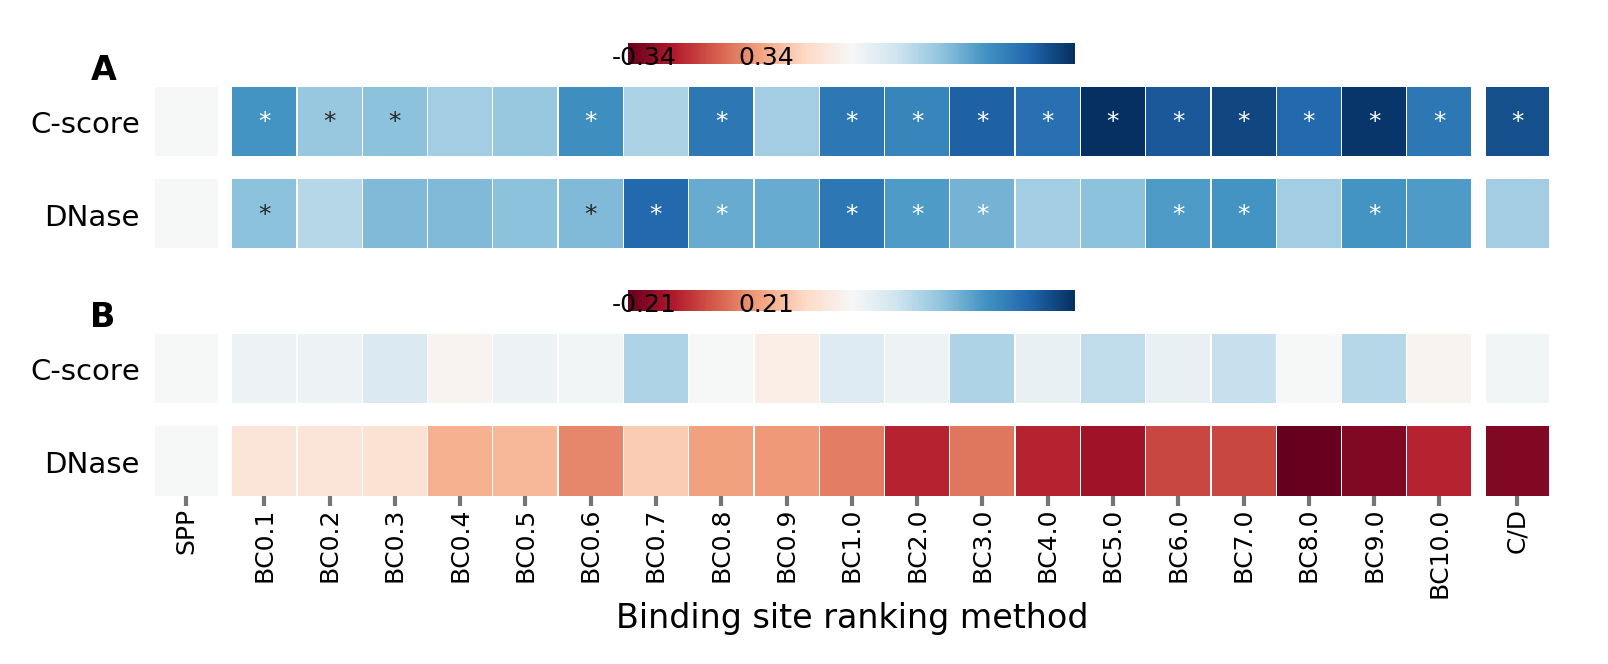

In [6]:
sns.set_context("paper")

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    gridspec_kw={'hspace': 0.2},
    figsize=(6,2), dpi=300)

axs[0].axis('off')
axs[1].axis('off')

################
gs = mpl.gridspec.GridSpecFromSubplotSpec(3, 5, subplot_spec=axs[0], hspace=0.4, wspace=0.05, height_ratios=[0.3,1,1], width_ratios=[1,6,7,6,1])

data_type = "humanGM12878"
max_list = []
df1, df_star1 = get_plotting_df("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/%s/tomtom_summary/" % data_type, nbp_list, rank_list, tool, top, improve=True)
max_list.append(df1.abs().max().max())
df2, df_star2 = get_plotting_df("/home/jg2447/slayman/motif_inference/result/DNase/%sDNase/tomtom_summary/" % data_type, nbp_list, rank_list, tool, top, improve=True)
max_list.append(df2.abs().max().max())

##
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[1,1:4])
ax3 = fig.add_subplot(gs[1,4])
ax_cbar = fig.add_subplot(gs[0,2])

ax1, ax2, ax3 = plt_heatmap_weight(df1.values[0], df_star1.values[0], (ax1, ax2, ax3), ax_cbar, "C-score", vmax=max(max_list))

ax1.text(-1, 1.1, "A", transform=ax1.transAxes, size=8, weight='bold')

##
ax1 = fig.add_subplot(gs[2,0])
ax2 = fig.add_subplot(gs[2,1:4])
ax3 = fig.add_subplot(gs[2,4])

ax1, ax2, ax3 = plt_heatmap_weight(df2.values[0], df_star2.values[0], (ax1, ax2, ax3), ax_cbar, "DNase", vmax=max(max_list))

##
ax_cbar.xaxis.set_ticklabels([])
ax_cbar.xaxis.set_tick_params(size=0)
ax_cbar.annotate("%.2f" % (-max(max_list)), xy=(-17,0.4), fontsize=6, xycoords="axes pixels")
ax_cbar.annotate("%.2f" % (max(max_list)), xy=(110,0.4), fontsize=6, xycoords="axes pixels")

########
gs = mpl.gridspec.GridSpecFromSubplotSpec(3, 5, subplot_spec=axs[1], hspace=0.4, wspace=0.05, height_ratios=[0.3,1,1], width_ratios=[1,6,7,6,1])

data_type = "humanK562"
max_list = []
df1, df_star1 = get_plotting_df("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/%s/tomtom_summary/" % data_type, nbp_list, rank_list, tool, top, improve=True)
max_list.append(df1.abs().max().max())
df2, df_star2 = get_plotting_df("/home/jg2447/slayman/motif_inference/result/DNase/%sDNase/tomtom_summary/" % data_type, nbp_list, rank_list, tool, top, improve=True)
max_list.append(df2.abs().max().max())

##
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[1,1:4])
ax3 = fig.add_subplot(gs[1,4])
ax_cbar = fig.add_subplot(gs[0,2])

ax1, ax2, ax3 = plt_heatmap_weight(df1.values[0], df_star1.values[0], (ax1, ax2, ax3), ax_cbar, "C-score", vmax=max(max_list))

ax1.text(-1, 1.1, "B", transform=ax1.transAxes, size=8, weight='bold')

##
ax1 = fig.add_subplot(gs[2,0])
ax2 = fig.add_subplot(gs[2,1:4])
ax3 = fig.add_subplot(gs[2,4])

ax1, ax2, ax3 = plt_heatmap_weight(df2.values[0], df_star2.values[0], (ax1, ax2, ax3), ax_cbar, "DNase", vmax=max(max_list))

##
ax_cbar.xaxis.set_ticklabels([])
ax_cbar.xaxis.set_tick_params(size=0)
ax_cbar.annotate("%.2f" % (-max(max_list)), xy=(-17,0.4), fontsize=6, xycoords="axes pixels")
ax_cbar.annotate("%.2f" % (max(max_list)), xy=(110,0.4), fontsize=6, xycoords="axes pixels")

########
ax1.get_xaxis().set_ticklabels(["SPP"],
                               fontsize=6, rotation=90)
ax1.get_xaxis().set_tick_params(size=2.5, pad=0, color="#757575")
ax2.get_xaxis().set_ticklabels(["BC0.1", "BC0.2", "BC0.3", "BC0.4", "BC0.5", "BC0.6", "BC0.7", "BC0.8", "BC0.9", "BC1.0", "BC2.0", "BC3.0", "BC4.0", "BC5.0", "BC6.0", "BC7.0", "BC8.0", "BC9.0", "BC10.0"],
                               fontsize=6, rotation=90)
ax2.get_xaxis().set_tick_params(size=2.5, pad=0, color="#757575")
ax3.get_xaxis().set_ticklabels(["C/D"],
                               fontsize=6, rotation=90)
ax3.get_xaxis().set_tick_params(size=2.5, pad=0, color="#757575")

ax2.set_xlabel("Binding site ranking method", fontsize=8, labelpad=1)

plt.savefig("./fig8.pdf", dpi="figure", bbox_inches="tight")